In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
data_path = "/content/drive/My Drive/Colab Notebooks/data/yelp_academic_dataset_review.json"


In [3]:
# نصب Java
!apt-get install openjdk-11-jdk -y


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra libatk-wrapper-java
  libatk-wrapper-java-jni libxt-dev libxtst6 libxxf86dga1 openjdk-11-jre
  x11-utils
Suggested packages:
  libxt-doc openjdk-11-demo openjdk-11-source visualvm mesa-utils
The following NEW packages will be installed:
  fonts-dejavu-core fonts-dejavu-extra libatk-wrapper-java
  libatk-wrapper-java-jni libxt-dev libxtst6 libxxf86dga1 openjdk-11-jdk
  openjdk-11-jre x11-utils
0 upgraded, 10 newly installed, 0 to remove and 35 not upgraded.
Need to get 6,920 kB of archives.
After this operation, 16.9 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-core all 2.37-2build1 [1,041 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-dejavu-extra all 2.37-2build1 [2,041 kB]
Get:3 http://archive.ubuntu.com/ubuntu jam

In [4]:
!apt-get install openjdk-11-jdk -y
!pip install pyspark


Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-11-jdk is already the newest version (11.0.27+6~us1-0ubuntu1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 35 not upgraded.


In [5]:
import os

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-11-openjdk-amd64"
os.environ["SPARK_HOME"] = "/usr/local/lib/python3.11/dist-packages/pyspark"


In [6]:
from pyspark.sql import SparkSession

spark = SparkSession.builder \
    .appName("Sentiment Analysis on Yelp Reviews") \
    .getOrCreate()


In [7]:
df = spark.read.json(data_path)

# تعداد کل ردیف‌ها:
total_rows = df.count()

# فقط ۵٪ داده‌ها رو انتخاب کن
df_sample = df.limit(int(total_rows * 0.05))

df_sample.show(5)


+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+
|         business_id|cool|               date|funny|           review_id|stars|                text|useful|             user_id|
+--------------------+----+-------------------+-----+--------------------+-----+--------------------+------+--------------------+
|XQfwVwDr-v0ZS3_Cb...|   0|2018-07-07 22:09:11|    0|KU_O5udG6zpxOg-Vc...|  3.0|If you decide to ...|     0|mh_-eMZ6K5RLWhZyI...|
|7ATYjTIgM3jUlt4UM...|   1|2012-01-03 15:28:18|    0|BiTunyQ73aT9WBnpR...|  5.0|I've taken a lot ...|     1|OyoGAe7OKpv6SyGZT...|
|YjUWPpI6HXG530lwP...|   0|2014-02-05 20:30:30|    0|saUsX_uimxRlCVr67...|  3.0|Family diner. Had...|     0|8g_iMtfSiwikVnbP2...|
|kxX2SOes4o-D3ZQBk...|   1|2015-01-04 00:01:03|    0|AqPFMleE6RsU23_au...|  5.0|Wow!  Yummy, diff...|     1|_7bHUi9Uuf5__HHc_...|
|e4Vwtrqf-wpJfwesg...|   1|2017-01-14 20:54:15|    0|Sx8TMOWLNuJBWer-0...|  4.0|Cute inter

In [8]:
from pyspark.sql.functions import col, lower, regexp_replace

df_clean = df_sample.select(
    col("review_id"), col("text"), col("stars")
).withColumn(
    "clean_text", lower(col("text"))
).withColumn(
    "clean_text", regexp_replace("clean_text", r"http\S+|www\S+|https\S+", "")
).withColumn(
    "clean_text", regexp_replace("clean_text", r"[^a-zA-Z\s]", "")
).withColumn(
    "clean_text", regexp_replace("clean_text", r"\s+", " ")
)

df_clean.select("clean_text").show(5, truncate=False)


+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|clean_text                                                                                                                                                                                       

In [9]:
from pyspark.sql.functions import when

df_labeled = df_clean.withColumn(
    "label", when(col("stars") >= 4, "positive")
            .when(col("stars") == 3, "neutral")
            .otherwise("negative")
)

df_labeled.select("stars", "label", "clean_text").show(5)


+-----+--------+--------------------+
|stars|   label|          clean_text|
+-----+--------+--------------------+
|  3.0| neutral|if you decide to ...|
|  5.0|positive|ive taken a lot o...|
|  3.0| neutral|family diner had ...|
|  5.0|positive|wow yummy differe...|
|  4.0|positive|cute interior and...|
+-----+--------+--------------------+
only showing top 5 rows



In [10]:
from pyspark.ml.feature import Tokenizer, StopWordsRemover, HashingTF, IDF, StringIndexer
from pyspark.ml import Pipeline

tokenizer = Tokenizer(inputCol="clean_text", outputCol="words_token")
remover = StopWordsRemover(inputCol="words_token", outputCol="words_clean")
hashingTF = HashingTF(inputCol="words_clean", outputCol="tf_features")
idf = IDF(inputCol="tf_features", outputCol="features")
indexer = StringIndexer(inputCol="label", outputCol="label_index")

pipeline = Pipeline(stages=[tokenizer, remover, hashingTF, idf, indexer])
model_pipeline = pipeline.fit(df_labeled)
df_prepared = model_pipeline.transform(df_labeled)


In [11]:
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import MulticlassClassificationEvaluator

# مدل لجستیک رگرشن
lr = LogisticRegression(featuresCol='features', labelCol='label_index')

# آموزش مدل
lr_model = lr.fit(df_prepared)

# پیش‌بینی
lr_predictions = lr_model.transform(df_prepared)

# ارزیابی
evaluator = MulticlassClassificationEvaluator(labelCol="label_index", predictionCol="prediction", metricName="accuracy")
lr_accuracy = evaluator.evaluate(lr_predictions)

print(f"Logistic Regression Accuracy: {lr_accuracy:.4f}")


Logistic Regression Accuracy: 0.9606


In [12]:
from pyspark.ml.classification import NaiveBayes

nb = NaiveBayes(featuresCol='features', labelCol='label_index', modelType="multinomial")

# آموزش مدل
nb_model = nb.fit(df_prepared)

# پیش‌بینی
nb_predictions = nb_model.transform(df_prepared)

# ارزیابی
nb_accuracy = evaluator.evaluate(nb_predictions)

print(f"Naive Bayes Accuracy: {nb_accuracy:.4f}")


Naive Bayes Accuracy: 0.8215


In [13]:
# تبدیل DataFrame به پانداس برای رسم نمودار
lr_pandas = lr_predictions.select("label_index", "prediction").toPandas()
nb_pandas = nb_predictions.select("label_index", "prediction").toPandas()


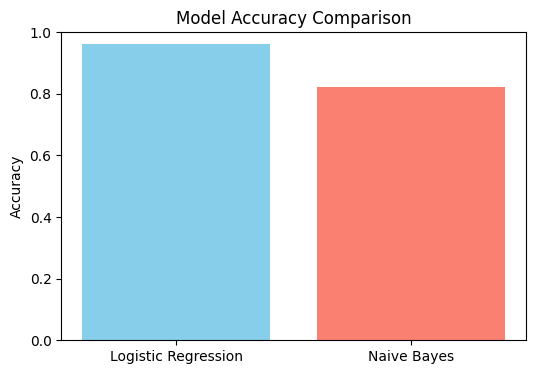

In [14]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Naive Bayes']
accuracies = [lr_accuracy, nb_accuracy]

plt.figure(figsize=(6,4))
plt.bar(models, accuracies, color=['skyblue', 'salmon'])
plt.title('Model Accuracy Comparison')
plt.ylim(0, 1)
plt.ylabel('Accuracy')
plt.show()


In [ ]:
import time

sample_sizes = [0.03, 0.04, 0.05]
times = []

for size in sample_sizes:
    print(f"\nTraining on {int(size*100)}% of data...")

    sampled_data = df_prepared.sample(withReplacement=False, fraction=size, seed=42)

    start_time = time.time()
    model = LogisticRegression(featuresCol='features', labelCol='label_index').fit(sampled_data)
    duration = time.time() - start_time

    times.append(duration)
    print(f"Done in {duration:.2f} seconds")



Training on 3% of data...
Done in 2320.15 seconds

Training on 4% of data...
Done in 2202.15 seconds

Training on 5% of data...
Done in 2204.77 seconds


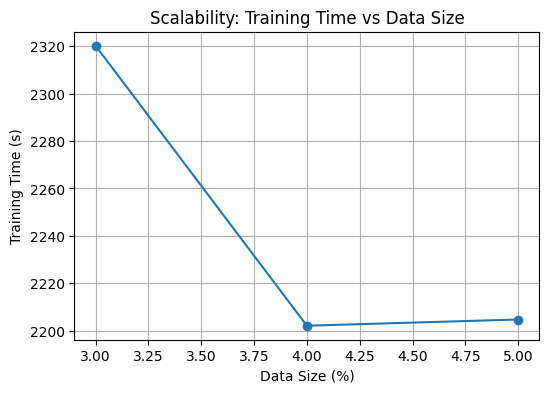

In [ ]:
import matplotlib.pyplot as plt

sample_sizes = [0.03, 0.04, 0.05]
times = [2320.15, 2202.15, 2204.77]

plt.figure(figsize=(6,4))
plt.plot([int(s*100) for s in sample_sizes], times, marker='o')
plt.title('Scalability: Training Time vs Data Size')
plt.xlabel('Data Size (%)')
plt.ylabel('Training Time (s)')
plt.grid(True)
plt.show()


In [15]:
# ذخیره مدل‌ها
lr_model.save("/content/drive/My Drive/Colab Notebooks/sentiment_model_lr")
nb_model.save("/content/drive/My Drive/Colab Notebooks/sentiment_model_nb")

# ذخیره نمونه‌ای از خروجی به CSV
lr_predictions.select("clean_text", "label_index", "prediction") \
    .sample(withReplacement=False, fraction=0.05, seed=42) \
    .coalesce(1).write.mode("overwrite").option("header", "true") \
    .csv("/content/drive/My Drive/Colab Notebooks/lr_results_csv")


In [16]:
!pip install pyspark streamlit pyngrok

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 37.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 50.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 5.8 MB/s eta 0:00:00


In [17]:
# ذخیره فایل رابط کاربری
%%writefile app.py
import pandas as pd
import streamlit as st
import glob

st.set_page_config(page_title="تحلیل احساسات کاربران", layout="centered")
st.title("📊 تحلیل احساسات کاربران Yelp")

# بارگذاری فایل CSV
csv_path = glob.glob("/content/drive/My Drive/Colab Notebooks/lr_results_csv/part-0000*.csv")[0]
df = pd.read_csv(csv_path)

st.subheader("🔍 پیش‌نمایش چند بررسی:")
st.dataframe(df.sample(10))

st.subheader("📈 توزیع احساسات پیش‌بینی‌شده:")
count_series = df['prediction'].value_counts().sort_index()
st.bar_chart(count_series)

st.subheader("📝 جستجوی متن بررسی:")
search_text = st.text_input("کلمه یا عبارتی وارد کن:")

if search_text:
    filtered = df[df['clean_text'].str.contains(search_text, case=False)]
    st.write(f"{len(filtered)} مورد پیدا شد:")
    st.dataframe(filtered)


Writing app.py


In [19]:
!ngrok config add-authtoken 2xzirHXosgJWahJmkMm3WtI8mqE_7R81Rop1ZpPFf41hPKaHZ

Authtoken saved to configuration file: /root/.config/ngrok/ngrok.yml


In [21]:
from pyngrok import ngrok

# اتصال به پورت به روش درست
public_url = ngrok.connect(8501, "http")  # پورت رو عددی بده، نه رشته
print(f"🌐 لینک نمایش رابط کاربری: {public_url}")

# اجرای Streamlit
!streamlit run app.py &


🌐 لینک نمایش رابط کاربری: NgrokTunnel: "https://87b3-34-169-215-234.ngrok-free.app" -> "http://localhost:8501"



  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://34.169.215.234:8501

  Stopping...
